# Examples of mapping real world fix-route buses into the simulation

In [2]:
from utils.util import *
from clients.METSRClient import METSRClient

# Example 1: Run the transit route in the simulation (open loop)

In [9]:
with open("input/Birmingham_transit_data/stop_to_link_mapping.json", "r") as f:
      stop2link = json.load(f)

for i in range(1):
      print(stop2link[list(stop2link.keys())[i]])

{'stops': [[-86.874491, 33.49398], [-86.859491, 33.500061], [-86.845215, 33.499688], [-86.841138, 33.498493], [-86.839618, 33.493104], [-86.834799, 33.490707], [-86.827743, 33.494075], [-86.820784, 33.497392], [-86.810902, 33.503497], [-86.806807, 33.505514], [-86.804913, 33.507946], [-86.806948, 33.510819], [-86.808124, 33.5127], [-86.786178, 33.52359], [-86.776278, 33.528352], [-86.771852, 33.530353], [-86.760746, 33.535633], [-86.750615, 33.541226]], 'stop_zones': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'assigned_links': ['-183945766#2', '7766854#18', '870847372#0', '183945767#4', '7745224', '-7749206#9', '-608662037#14', '-608662037#1', '-422477569', '746300584#9', '771558766#6', '-751530242#7', '259309286#1', '165419545#0', '-165419545#17', '165419545#23', '-736505309#3', '-7737602#2']}


In [10]:
from utils.util import *
from clients.METSRClient import METSRClient

In [11]:
config = read_run_config("configs/run_interactive_Birmingham.json")

In [12]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)


No port number specified, find available ports for simulation instances
['output/Birmingham_20250706_010828_seed_42']


In [13]:
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port = config.ports[0], verbose=False, timeout=300) 

Attempt to connect to ws://localhost:61537 failed. Waiting for 10 seconds before trying again... (5 attempts remaining)
Connection established!


In [14]:
# add the first bus route to the simulation
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    sim_client.add_bus_route(routeName=route_name, zone = route_info["stop_zones"], road= route_info["assigned_links"])
    break

Route Name: 100_36_1


In [15]:
route_info = sim_client.query_bus_route("100_36_1")
route_info

{'DATA': [{'stopRoads': ['-183945766#2',
    '7766854#18',
    '870847372#0',
    '183945767#4',
    '7745224',
    '-7749206#9',
    '-608662037#14',
    '-608662037#1',
    '-422477569',
    '746300584#9',
    '771558766#6',
    '-751530242#7',
    '259309286#1',
    '165419545#0',
    '-165419545#17',
    '165419545#23',
    '-736505309#3',
    '-7737602#2'],
   'routeID': 0,
   'stopZones': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'routeName': '100_36_1'}],
 'TYPE': 'ANS_getBusRoute'}

In [16]:
# add a bus run to the first route
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    print(sim_client.add_bus_run(routeName = route_name, departTime = [0] * len(route_info['stop_zones'])))
    break

Route Name: 100_36_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '100_36_1'}], 'TYPE': 'CTRL_addBusRun'}


In [17]:
sim_client.tick(600)

In [18]:
bus_info = sim_client.query_route_bus("100_36_1")
bus_info

{'DATA': [{'routeID': 0, 'busIDs': [1000], 'routeName': '100_36_1'}],
 'TYPE': 'ANS_getBusWithRoute'}

In [19]:
sim_client.query_bus(1000)

{'DATA': [{'battery_state': 246.70413694616798,
   'route': '100_36_1',
   'current_stop': -1,
   'pass_num': 0,
   'ID': 1000}],
 'TYPE': 'ANS_bus'}

In [21]:
# collect the vehicle path
xs, ys = [], []

# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      query_res = sim_client.query_vehicle(1000)
      xs.append(query_res['DATA'][0]['x'])
      ys.append(query_res['DATA'][0]['y'])

      sim_client.tick(5)

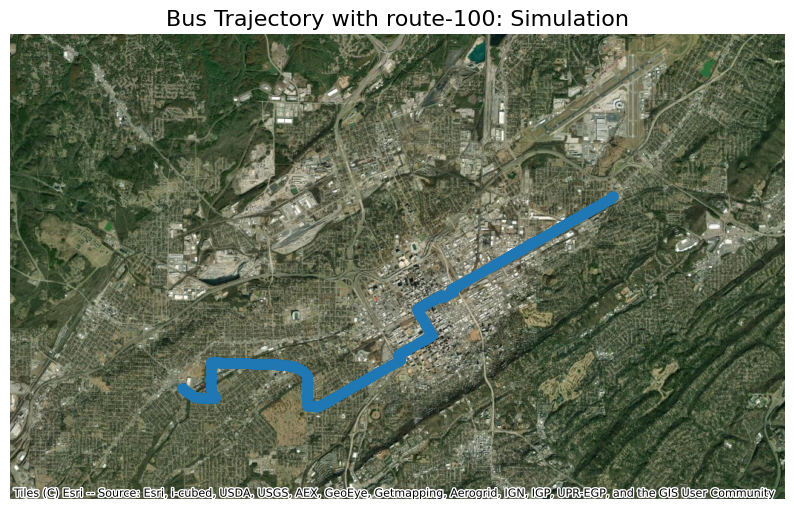

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

# add the NYC map
gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-100: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory.png", bbox_inches='tight')
plt.show()


In [ ]:
sim_client.terminate()

# Example 2: Bus run to simulation mapping (closed loop)

In [250]:
from utils.util import *
from clients.METSRClient import METSRClient

In [251]:
def compressed_trajectory_to_path(trajectory, stop_list):
      visited_links = [t['linkID'] for t in trajectory]

      # filter the stop incrementally
      stop_masks = []
      current_ind = 0
      for l in stop_list['assigned_links']:
            if l in visited_links[current_ind:]:
                  stop_masks.append(True)
                  current_ind = visited_links.index(l, current_ind) + 1
            else:
                  stop_masks.append(False)
      stop_masks[0] = True # the first stop (depot) is always visited

      stop_zones = [stop_list['stop_zones'][i] for i in range(len(stop_list['stop_zones'])) if stop_masks[i]]

      stop_links = [stop_list['assigned_links'][i] for i in range(len(stop_list['assigned_links'])) if stop_masks[i]]

      paths = [stop_links[0]]
      
      current_road = None
      segment = []
      current_stop = 1
      for t in trajectory:
            if t['linkID'] != current_road:
                  current_road = t['linkID']
                  if t['linkID'] == stop_links[current_stop]:
                        # check if the segment ends
                        if len(segment) > 0:
                              segment.append(t['linkID'])
                              paths.append(segment)
                              segment = []
                        current_stop += 1
                        if(current_stop >= len(stop_links)):
                              break
                  segment.append(t['linkID'])
      return stop_zones, stop_links, paths

In [252]:
config = read_run_config("configs/run_interactive_Birmingham.json")

In [253]:
with open("input/Birmingham_transit_data/stop_to_link_mapping.json", "r") as f:
      stop2link = json.load(f)

for i in range(1):
      print(stop2link[list(stop2link.keys())[i]])

{'stops': [[-86.874491, 33.49398], [-86.859491, 33.500061], [-86.845215, 33.499688], [-86.841138, 33.498493], [-86.839618, 33.493104], [-86.834799, 33.490707], [-86.827743, 33.494075], [-86.820784, 33.497392], [-86.810902, 33.503497], [-86.806807, 33.505514], [-86.804913, 33.507946], [-86.806948, 33.510819], [-86.808124, 33.5127], [-86.786178, 33.52359], [-86.776278, 33.528352], [-86.771852, 33.530353], [-86.760746, 33.535633], [-86.750615, 33.541226]], 'stop_zones': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'assigned_links': ['-183945766#2', '7766854#18', '870847372#0', '183945767#4', '7745224', '-7749206#9', '-608662037#14', '-608662037#1', '-422477569', '746300584#9', '771558766#6', '-751530242#7', '259309286#1', '165419545#0', '-165419545#17', '165419545#23', '-736505309#3', '-7737602#2']}


In [254]:
with open("input/Birmingham_transit_data/compressed_trajectories_all_runs.json", "r") as f:
      busrun2trajectory = json.load(f)

for i in range(1):
      print(busrun2trajectory[list(busrun2trajectory.keys())[i]])

{'start_time': '2025-02-21T10:24:38.761877', 'duration_seconds': 32652.966827, 'route_variant': '1_2_1', 'compressed_trajectory': [{'time_offset': 0.0, 'linkID': '-7780944#12', 'distance_to_next_link': 93.47448965470214, 'type': 'start'}, {'time_offset': 22.568948, 'linkID': '-7780944#12', 'distance_to_next_link': 0.0, 'type': 'end'}, {'time_offset': 22.568948, 'linkID': '7780944#14', 'distance_to_next_link': 24.55289238287473, 'type': 'start'}, {'time_offset': 45.22725, 'linkID': '7780944#14', 'distance_to_next_link': 0.0, 'type': 'end'}, {'time_offset': 45.22725, 'linkID': '106664316#0', 'distance_to_next_link': 264.6361947127525, 'type': 'start'}, {'time_offset': 67.860319, 'linkID': '106664316#0', 'distance_to_next_link': 0.0, 'type': 'end'}, {'time_offset': 67.860319, 'linkID': '106664316#5', 'distance_to_next_link': 296.8475875087078, 'type': 'start'}, {'time_offset': 90.575589, 'linkID': '106664316#5', 'distance_to_next_link': 0.0, 'type': 'end'}, {'time_offset': 90.575589, 'lin

In [255]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['output/Birmingham_20250707_005730_seed_42']


In [256]:
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port = config.ports[0], verbose=False, timeout=300) 

Attempt to connect to ws://localhost:56794 failed. Waiting for 10 seconds before trying again... (5 attempts remaining)
Connection established!


In [257]:
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Bus Run Name: {bus_run_name}")
    print(f"Route Name: {compressed_trajectory['route_variant']}")
    route_info = stop2link[compressed_trajectory['route_variant']]

    zone_list, road_list, path_list = compressed_trajectory_to_path(compressed_trajectory['compressed_trajectory'], route_info)

    print(sim_client.add_bus_route(compressed_trajectory['route_variant'], zone_list, road_list, path_list[1:]))
    break

Bus Run Name: 1_101_312
Route Name: 1_2_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '1_2_1'}], 'TYPE': 'CTRL_addBusRouteWithPath'}


In [258]:
# add a bus run to the first route
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Route Name: {compressed_trajectory['route_variant']}")
    print(sim_client.add_bus_run(routeName = [compressed_trajectory['route_variant'],compressed_trajectory['route_variant']], departTime = [[0] * len(zone_list), [0] * len(zone_list)]))
    break

Route Name: 1_2_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '1_2_1'}, {'STATUS': 'OK', 'routeName': '1_2_1'}], 'TYPE': 'CTRL_addBusRun'}


In [259]:
bus_info = sim_client.query_route_bus("1_2_1")

# wait until a bus is assigned to the route (depending on whether there is a bus at the beginning of the stop)
while len(bus_info['DATA'][0]['busIDs']) == 0:
      sim_client.tick(120)
      bus_info = sim_client.query_route_bus("1_2_1")

In [260]:
bus_info

{'DATA': [{'routeID': 0, 'busIDs': [1036], 'routeName': '1_2_1'}],
 'TYPE': 'ANS_getBusWithRoute'}

In [261]:
sim_client.query_vehicle(1036)

{'DATA': [{'acc': 0.0,
   'road': '-741878530#0',
   'bearing': -180.0,
   'x': -87.01063967183053,
   'y': 33.37570333783184,
   'dist': 53.39662766435732,
   'ID': 1036,
   'state': 0,
   'v_type': 2,
   'speed': 0.0,
   'lane': 0}],
 'TYPE': 'ANS_vehicle'}

In [262]:
compressed_trajectory['compressed_trajectory']

[{'time_offset': 0.0,
  'linkID': '-7780944#12',
  'distance_to_next_link': 93.47448965470214,
  'type': 'start'},
 {'time_offset': 22.568948,
  'linkID': '-7780944#12',
  'distance_to_next_link': 0.0,
  'type': 'end'},
 {'time_offset': 22.568948,
  'linkID': '7780944#14',
  'distance_to_next_link': 24.55289238287473,
  'type': 'start'},
 {'time_offset': 45.22725,
  'linkID': '7780944#14',
  'distance_to_next_link': 0.0,
  'type': 'end'},
 {'time_offset': 45.22725,
  'linkID': '106664316#0',
  'distance_to_next_link': 264.6361947127525,
  'type': 'start'},
 {'time_offset': 67.860319,
  'linkID': '106664316#0',
  'distance_to_next_link': 0.0,
  'type': 'end'},
 {'time_offset': 67.860319,
  'linkID': '106664316#5',
  'distance_to_next_link': 296.8475875087078,
  'type': 'start'},
 {'time_offset': 90.575589,
  'linkID': '106664316#5',
  'distance_to_next_link': 0.0,
  'type': 'end'},
 {'time_offset': 90.575589,
  'linkID': '7739067#4',
  'distance_to_next_link': 52.32028702638022,
  'type

In [ ]:
# collect the vehicle path
xs, ys = [], []

current_ind = 0
# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      # while compressed_trajectory['compressed_trajectory'][current_ind+1]['time_offset'] < i:
      #       current_ind += 1
      # link = compressed_trajectory['compressed_trajectory'][current_ind]['linkID']
      # distance = compressed_trajectory['compressed_trajectory'][current_ind]['distance_to_next_link'] * (i - compressed_trajectory['compressed_trajectory'][current_ind]['time_offset'])/(compressed_trajectory['compressed_trajectory'][current_ind + 1]['time_offset'] - compressed_trajectory['compressed_trajectory'][current_ind]['time_offset'])
      # sim_client.teleport_trace_replay_vehicle(1036, link , 0, distance)
      query_res = sim_client.query_vehicle(1036)
      xs.append(query_res['DATA'][0]['x'])
      ys.append(query_res['DATA'][0]['y'])

      sim_client.tick(5)

AssertionError: KO

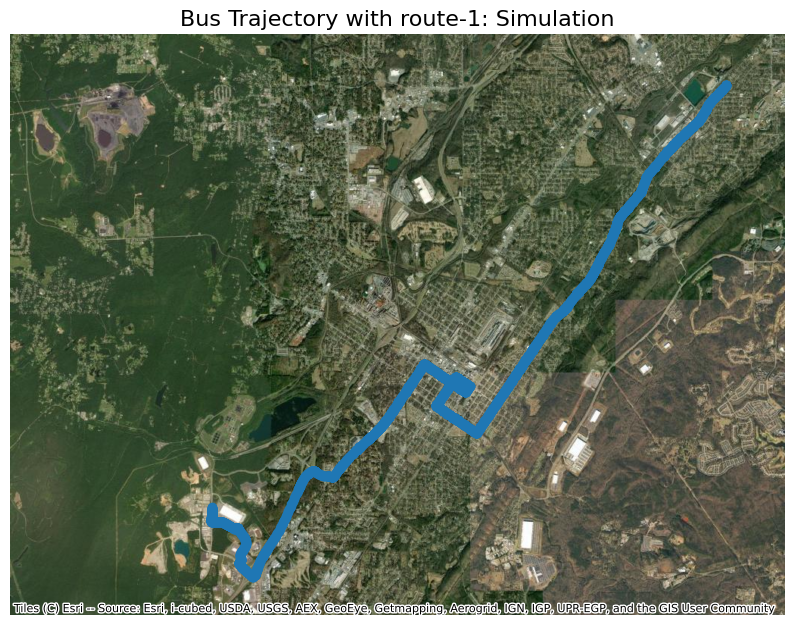

In [201]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

# add the NYC map
gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-1: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory2.png", bbox_inches='tight')
plt.show()


In [249]:
sim_client.terminate()